<a href="https://colab.research.google.com/github/Noah-Gallego/Plot-A-Thon/blob/main/Justin/gamer_study_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Install Libraries
!pip3 install pandas
!pip install lightgbm

In [17]:
# Import Libraries
import pandas as pd

url = 'https://raw.githubusercontent.com/Noah-Gallego/Plot-A-Thon/main/gamer_study_raw.csv'
df = pd.read_csv(url)

In [18]:
generations = {
    'Gen Z': 'Z',
    'Boomer': 'B',
    'Millennial': 'M',
    'Gen X': 'X',
    'Silent': 'S'
}

genders = {
    'Female': 'F',
    'Male': 'M',
    'Nonbinary/Other': 'N',
    'MALE': 'M',
    'femal': 'F'
}

races = {
    'White/Caucasian': 'W',
    'Hispanic': 'H',
    'Black/African American': 'B',
    'Other': 'O',
    'Asian/Pacific Islander': 'A',
    'White': 'W',
    'Native American/Alaskan': 'N'
}

lgbt_identifications = {
    'Prefer not to say': 2,
    'Yes': 1,
    'No': 0
}
df['is_player'] = df['is_player'].map(lambda x: True if x == 'TRUE' or x == 'Yes' else False)
df = df.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
df = df.apply(lambda x: x.map(generations) if x.name == 'generation' else x)
df = df.apply(lambda x: x.map(genders) if x.name == 'gender' else x)
df = df.apply(lambda x: x.map(races) if x.name == 'race_ethnicity_primary' else x)
df = df.apply(lambda x: x.map(lgbt_identifications) if x.name == 'lgbt_identification' else x)

In [30]:
# One Hot Encoding
objs = ['generation','gender','race_ethnicity_primary']
X = df.drop(columns = ['children_play_games'])
Y = df['children_play_games']
X = pd.get_dummies(X, columns=objs, dummy_na=True)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import xgboost as xgb

clf = xgb.XGBClassifier(tree_method="hist")

search = RandomizedSearchCV(
    clf,
    param_distributions={
        "max_depth": [3,4,5,6],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7,0.8,1.0],
        "colsample_bytree": [0.7,0.8,1.0],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=123),
    scoring="neg_log_loss",
    n_iter=30,
    n_jobs=-1,
    verbose=1
)

search.fit(X, Y)
print(search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'subsample': 1.0, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [34]:
best_model = search.best_estimator_
booster = best_model.get_booster()
score = booster.get_score(importance_type="gain")

import pandas as pd

importance = (
    pd.Series(score)
      .reindex(X_train.columns, fill_value=0)
      .sort_values(ascending=False)
)

print(importance.head(30))

parent_uses_parental_controls                    107.975571
esrb_aware                                        66.215721
esrb_regular_use                                  55.408436
bought_in_game_content_for_child                  30.611067
parent_play_reason_family_time                    27.044304
parent_plays_with_children                        20.496084
pc_activity_reports                               13.946899
pc_set_time_limits                                13.338630
is_parent                                          5.647581
pc_manage_spending                                 3.808676
gender_nan                                         2.617039
comm_pref_discord                                  0.888625
play_with_other_family                             0.670912
race_ethnicity_primary_B                           0.463183
att_creative_skills_likert                         0.342324
agree_games_introduce_new_friends_binary           0.302092
teach_teamwork_likert                   

In [23]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=123,
    n_jobs=-1,
)

model.fit(X_train, y_train)

gain = model.booster_.feature_importance(importance_type="gain")
imp = (pd.Series(gain, index=X_train.columns)
         .sort_values(ascending=False))

print(imp.head(30))

[LightGBM] [Info] Number of positive: 417, number of negative: 764
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 647
[LightGBM] [Info] Number of data points in the train set: 1181, number of used features: 119
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.353091 -> initscore=-0.605482
[LightGBM] [Info] Start training from score -0.605482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

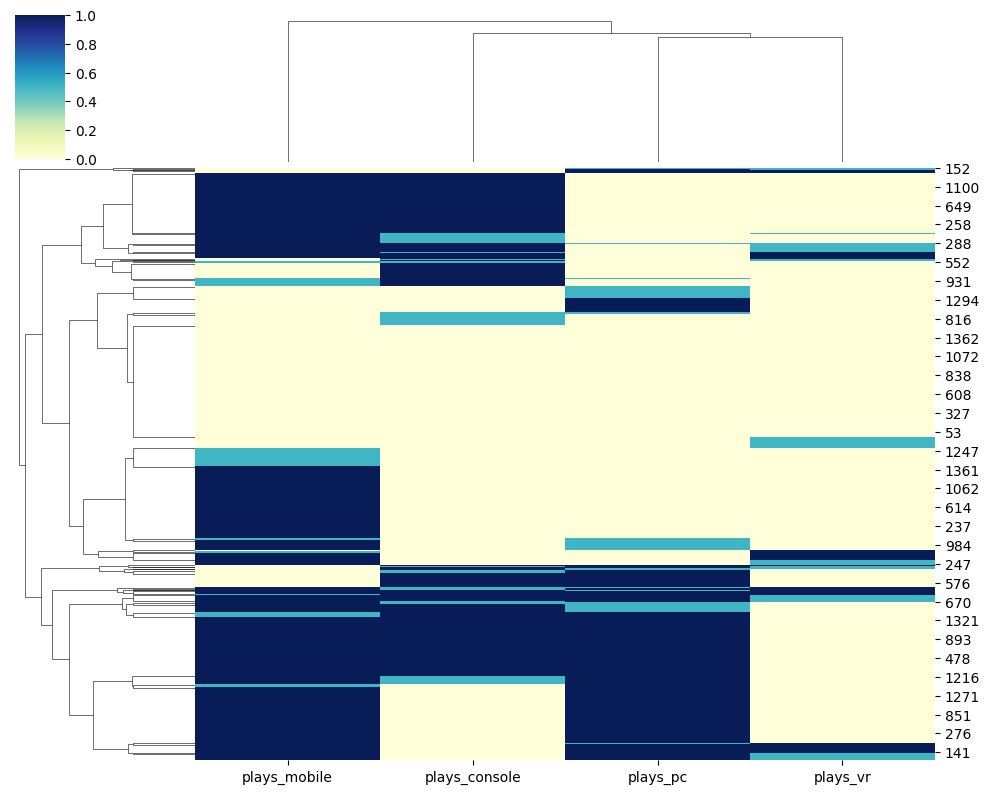

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.clustermap(playsdf, cmap='YlGnBu',robust=True,figsize=(10,8))
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

antecedents
consequents
support
confidence
lift


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag